# 日本傳統漫畫和韓國漫畫的比較研究

## 研究動機與目的
在全球數位化的浪潮下，漫畫產業正從傳統紙本模式逐漸轉向數位化。其中，以條漫（Webtoon）為主的韓國數位漫畫，因其符合手機閱讀習慣、採用向下捲動形式，以及全彩長條式的視覺呈現，而在全球市場快速崛起，塑造出另一種對於漫畫的製作與閱讀模式。面對條漫與傳統出版模式之間轉變與競爭，本研究希望探究韓國條漫的成功是否對日本傳統漫畫出版產生影響。

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import pearsonr
df = pd.read_excel("manga_panel_template_2015_2024.xlsx")

In [7]:
pd.read_excel("manga_panel_template_2015_2024.xlsx", sheet_name = 0)
manga = pd.read_excel('manga_panel_template_2015_2024.xlsx', sheet_name = 0)
manga.head()

,Year,KR_Comics_100M_KRW,JP_Print_100M_JPY,JP_Digital_100M_JPY,FX_KRW_USD,FX_JPY_USD
0,2015,2980,2102,1169,0.000884,0.008269
1,2016,3790,1947,1491,0.000863,0.009219
2,2017,6400,1668,1742,0.000886,0.008918
3,2018,8050,1588,2002,0.000910,0.009050
4,2019,10132,1665,2593,0.000858,0.009174


數據整理
將兩者匯率轉換成美金，並以百萬為單位

In [10]:
df["KR_Comics_M_USD"] = df["KR_Comics_100M_KRW"] * 1e8 * df["FX_KRW_USD"] / 1e6
#把韓圜從億韓元轉為韓元，再換匯率成美金(統一以美金作為比較單位)
df["JP_Print_M_USD"]   = df["JP_Print_100M_JPY"]   * 1e8 * df["FX_JPY_USD"] / 1e6
df["JP_Digital_M_USD"] = df["JP_Digital_100M_JPY"] * 1e8 * df["FX_JPY_USD"] / 1e6
#把日圓從億日元轉為日元，再換匯率成美金(統一以美金作為比較單位)

df["JP_Total_M_USD"] = df["JP_Print_M_USD"] + df["JP_Digital_M_USD"]

df.head()

,Year,KR_Comics_100M_KRW,JP_Print_100M_JPY,JP_Digital_100M_JPY,FX_KRW_USD,FX_JPY_USD,KR_Comics_M_USD,JP_Print_M_USD,JP_Digital_M_USD,JP_Total_M_USD
0,2015,2980,2102,1169,0.000884,0.008269,263.4320,1738.1438,966.6461,2704.7899
1,2016,3790,1947,1491,0.000863,0.009219,327.0770,1794.9393,1374.5529,3169.4922
2,2017,6400,1668,1742,0.000886,0.008918,567.0400,1487.5224,1553.5156,3041.0380
3,2018,8050,1588,2002,0.000910,0.009050,732.5500,1437.1400,1811.8100,3248.9500
4,2019,10132,1665,2593,0.000858,0.009174,869.3256,1527.4710,2378.8182,3906.2892


# 計算年成長率
日本市場因為發展較早，原先有較盛收的IP，因此日本市場基期很大，直接比「金額」會被基期影響
所以使用成長率來了解「趨勢方向」與「變化幅度」，適合做跨國比較

In [4]:
df["KR_Comics_Growth"]   = df["KR_Comics_M_USD"].pct_change()
df["JP_Total_Growth"]    = df["JP_Total_M_USD"].pct_change()
df["JP_Print_Growth"]    = df["JP_Print_M_USD"].pct_change()
df["JP_Digital_Growth"]  = df["JP_Digital_M_USD"].pct_change()

In [5]:
df[["Year",
    "KR_Comics_Growth", "JP_Total_Growth",
    "JP_Print_Growth", "JP_Digital_Growth"
   ]].head(5)

,Year,KR_Comics_Growth,JP_Total_Growth,JP_Print_Growth,JP_Digital_Growth
0,2015,NaN,NaN,NaN,NaN
1,2016,0.241599,0.171807,0.032676,0.421982
2,2017,0.733659,-0.040528,-0.171269,0.130197
3,2018,0.291884,0.068369,-0.033870,0.166264
4,2019,0.186712,0.202324,0.062855,0.312951


In [12]:
Part1_df = df.dropna(subset=["KR_Comics_M_USD", "JP_Total_M_USD"]).copy()

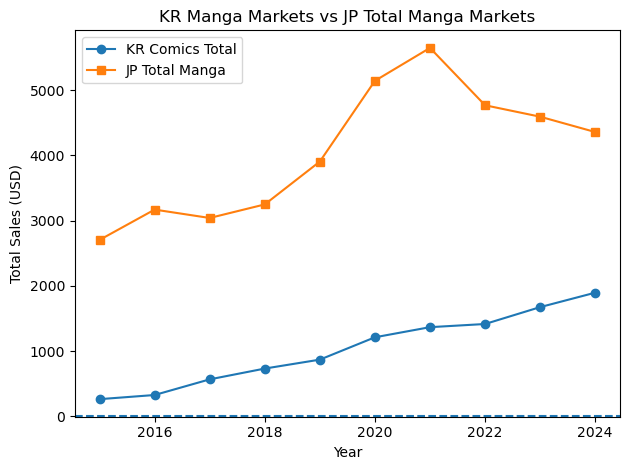

In [18]:
plt.figure()
plt.plot(Part1_df["Year"], Part1_df["KR_Comics_M_USD"], marker="o", label="KR Comics Total")
plt.plot(Part1_df["Year"], Part1_df["JP_Total_M_USD"],  marker="s", label="JP Total Manga")
plt.axhline(0, linestyle="--")
plt.xlabel("Year")
plt.ylabel("Total Sales (USD)")
plt.title("KR Manga Markets vs JP Total Manga Markets")
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
pearson_Q1, pval_Q1 = pearsonr(
    Part1_df["KR_Comics_M_USD"],
    Part1_df["JP_Total_M_USD"]
)
print("Level 1 - Pearson correlation (KR_Comics_M_USD vs JP_Total_M_USD):")
print(f"  r = {pearson_Q1:.3f}, p-value = {pval_Q1:.3f}")

Level 1 - Pearson correlation (KR_Comics_M_USD vs JP_Total_M_USD):
  r = 0.792, p-value = 0.006


# 問題一:日本漫畫市場電子化趨勢與韓國 Webtoon 的崛起是否時間上同步？是否存在「衝擊關係」

檢查兩國總漫畫市場是否存在「成長趨勢上的相關性」

In [6]:
Q1_df = df.dropna(subset=["KR_Comics_Growth", "JP_Total_Growth"]).copy()

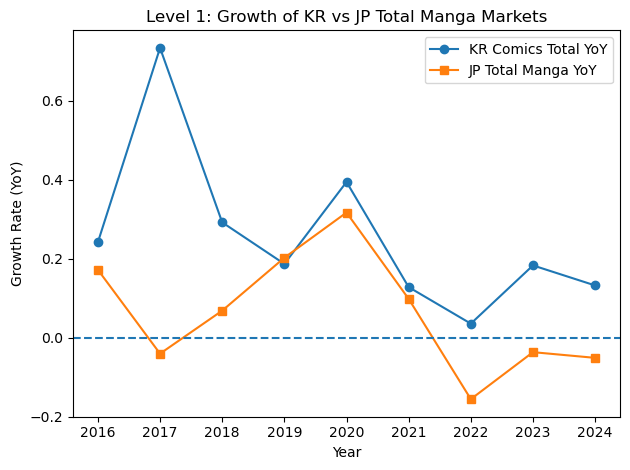

In [7]:
plt.figure()
plt.plot(Q1_df["Year"], Q1_df["KR_Comics_Growth"], marker="o", label="KR Comics Total YoY")
plt.plot(Q1_df["Year"], Q1_df["JP_Total_Growth"],        marker="s", label="JP Total Manga YoY")
plt.axhline(0, linestyle="--")
plt.xlabel("Year")
plt.ylabel("Growth Rate (YoY)")
plt.title("Level 1: Growth of KR vs JP Total Manga Markets")
plt.legend()
plt.tight_layout()
plt.show()

韓國成長率有較高的爆發力，日本成長幅度相對溫和，兩者的成長軌跡並未呈現明顯同步

In [8]:
pearson_Q1, pval_Q1 = pearsonr(
    Q1_df["KR_Comics_Growth"],
    Q1_df["JP_Total_Growth"]
)
print("Level 1 - Pearson correlation (KR_Total_Growth vs JP_Total_Growth):")
print(f"  r = {pearson_Q1:.3f}, p-value = {pval_Q1:.3f}")

Level 1 - Pearson correlation (KR_Total_Growth vs JP_Total_Growth):
  r = 0.162, p-value = 0.678


韓國漫畫總市場的年成長率與日本總漫畫市場的成長率之間僅呈現極弱相關（r = 0.162），且 p-value 遠高於 0.05，顯示統計上不具顯著性。

In [9]:
X_lvl1 = sm.add_constant(Q1_df["KR_Comics_Growth"])  # 自變數：韓國總市場成長率
y_lvl1 = Q1_df["JP_Total_Growth"]                          # 因變數：日本總市場成長率

model_lvl1 = sm.OLS(y_lvl1, X_lvl1).fit()
print("\nLevel 1 - OLS Regression: JP_Total_Growth ~ KR_Comics_Growth")
print(model_lvl1.summary())


Level 1 - OLS Regression: JP_Total_Growth ~ KR_Comics_Growth
                            OLS Regression Results                            
Dep. Variable:        JP_Total_Growth   R-squared:                       0.026
Model:                            OLS   Adj. R-squared:                 -0.113
Method:                 Least Squares   F-statistic:                    0.1876
Date:                Fri, 05 Dec 2025   Prob (F-statistic):              0.678
Time:                        12:49:44   Log-Likelihood:                 4.9914
No. Observations:                   9   AIC:                            -5.983
Df Residuals:                       7   BIC:                            -5.588
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------

C:\Users\ASUS\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=9 observations were given.
  return hypotest_fun_in(*args, **kwds)


OLS 迴歸的解釋力亦相當有限，僅約 2.6%。也就是說，韓國 Webtoon 的高速成長並未對日本漫畫整體市場造成可觀察的推動或衝擊，其市場變化似乎更偏向各自獨立運行。

# 日本電子漫畫 vs 韓國電子漫畫
目的:比較內容相同型態的市場競爭力

In [14]:

# 先計算日本電子占比：電子 / (紙本 + 電子)
df["JP_Digital_Share"] = df["JP_Digital_M_USD"] / df["JP_Total_M_USD"]

lvl2_df = df.dropna(subset=[
    "KR_Comics_Growth",
    "JP_Print_Growth",
    "JP_Digital_Share"
]).copy()

df[["Year",
    "JP_Digital_Share"
   ]]

,Year,JP_Digital_Share
0,2015,0.357383
1,2016,0.433682
2,2017,0.510850
3,2018,0.557660
4,2019,0.608971
5,2020,0.621931
6,2021,0.663441
7,2022,0.718595
8,2023,0.750000
9,2024,0.776767


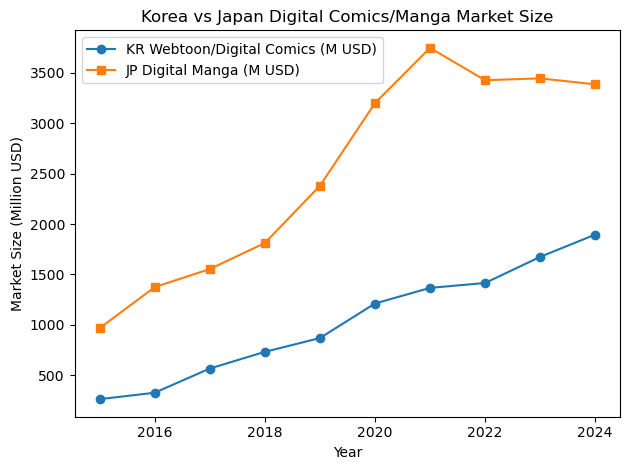

In [17]:
plt.figure()
plt.plot(df["Year"], df["KR_Comics_M_USD"], marker="o", label="KR Webtoon/Digital Comics (M USD)")
plt.plot(df["Year"], df["JP_Digital_M_USD"], marker="s", label="JP Digital Manga (M USD)")
plt.xlabel("Year")
plt.ylabel("Market Size (Million USD)")
plt.title("Korea vs Japan Digital Comics/Manga Market Size")
plt.legend()
plt.tight_layout()
plt.show()

日本電子漫畫的市場規模一直大於韓國
韓國電子漫畫的成長速度在早期呈現更高斜率

In [20]:
df["KR_Digital_Growth"] = df["KR_Comics_M_USD"].pct_change()
df["JP_Digital_Growth"] = df["JP_Digital_M_USD"].pct_change()

growth_df = df.dropna(subset=["KR_Comics_Growth", "JP_Digital_Growth"]).copy()


In [21]:
df[["Year",
    "KR_Digital_Growth", "JP_Digital_Growth"
   ]].head(5)

,Year,KR_Digital_Growth,JP_Digital_Growth
0,2015,NaN,NaN
1,2016,0.241599,0.421982
2,2017,0.733659,0.130197
3,2018,0.291884,0.166264
4,2019,0.186712,0.312951


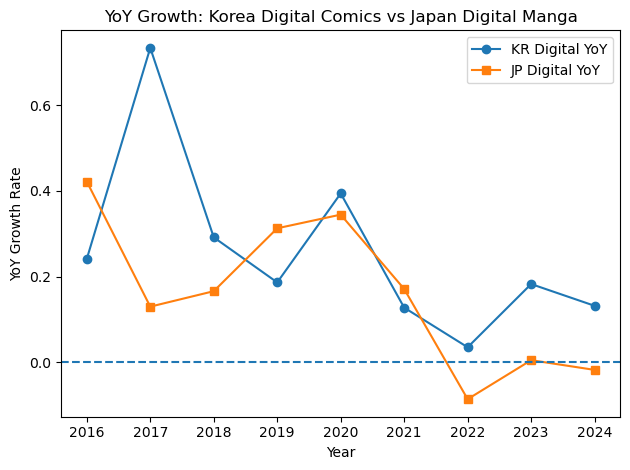

In [22]:
plt.figure()
plt.plot(growth_df["Year"], growth_df["KR_Digital_Growth"], marker="o", label="KR Digital YoY")
plt.plot(growth_df["Year"], growth_df["JP_Digital_Growth"], marker="s", label="JP Digital YoY")
plt.axhline(0, linestyle="--")
plt.xlabel("Year")
plt.ylabel("YoY Growth Rate")
plt.title("YoY Growth: Korea Digital Comics vs Japan Digital Manga")
plt.legend()
plt.tight_layout()
plt.show()

波動方向不一致，且韓國的年成長率在多數年份明顯高於日本

In [23]:
r, p = pearsonr(
    growth_df["KR_Digital_Growth"],
    growth_df["JP_Digital_Growth"]
)

print("Pearson correlation: KR_Digital_Growth vs JP_Digital_Growth")
print(f"  r = {r:.3f}, p-value = {p:.3f}")


Pearson correlation: KR_Digital_Growth vs JP_Digital_Growth
  r = 0.289, p-value = 0.450


r = 0.289 相關性弱，p =0.45 是不顯著，代表韓國電子漫畫和日本電子漫畫是各自成長發展

In [24]:
X = sm.add_constant(growth_df["KR_Digital_Growth"])  # 自變數：韓國數位漫畫成長率
y = growth_df["JP_Digital_Growth"]                  # 因變數：日本數位漫畫成長率

model = sm.OLS(y, X).fit()
print("\nOLS Regression: JP_Digital_Growth ~ KR_Digital_Growth")
print(model.summary())

alpha = model.params["const"]
beta  = model.params["KR_Digital_Growth"]

print("\nRegression Coefficients:")
print(f"  Intercept (α) = {alpha:.3f}")
print(f"  Slope (β)     = {beta:.3f}")


OLS Regression: JP_Digital_Growth ~ KR_Digital_Growth
                            OLS Regression Results                            
Dep. Variable:      JP_Digital_Growth   R-squared:                       0.084
Model:                            OLS   Adj. R-squared:                 -0.047
Method:                 Least Squares   F-statistic:                    0.6401
Date:                Fri, 05 Dec 2025   Prob (F-statistic):              0.450
Time:                        13:28:29   Log-Likelihood:                 3.8793
No. Observations:                   9   AIC:                            -3.759
Df Residuals:                       7   BIC:                            -3.364
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------

C:\Users\ASUS\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=9 observations were given.
  return hypotest_fun_in(*args, **kwds)


OLS 模型雖呈現正迴歸斜率，但其 R² 仍僅約 8.4%，說明韓國數位漫畫市場的成長對日本數位漫畫市場的變化並沒有明顯的解釋力。

Text(0.5, 1.0, 'Scatter: KR vs JP Digital Manga Growth')

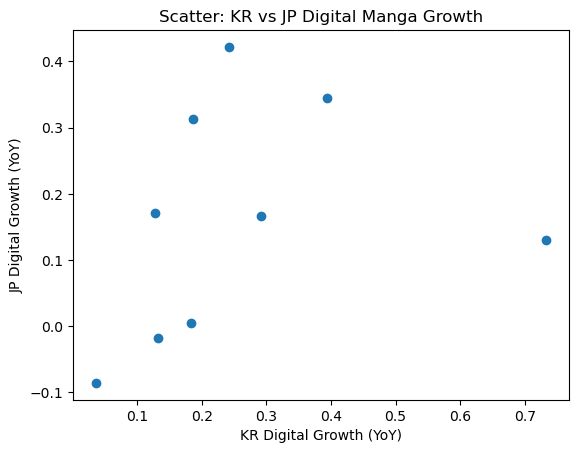

In [25]:
plt.figure()
plt.scatter(growth_df["KR_Digital_Growth"], growth_df["JP_Digital_Growth"])
plt.xlabel("KR Digital Growth (YoY)")
plt.ylabel("JP Digital Growth (YoY)")
plt.title("Scatter: KR vs JP Digital Manga Growth")

從散佈圖可觀察到，日本電子漫畫的成長率並未隨著韓國 webtoon 的成長呈現一致方向的變化，數據點分散且缺乏明顯線性結構，反映兩者關聯性有限。

整體而言，韓國 webtoon 的快速成長並未造成日本電子漫畫市場的明顯帶動或擠壓；兩國數位漫畫市場更像是受各自產業政策、平台發展與本地讀者習慣所驅動，而非呈現跨國性的直接因果
關係。